In [283]:
import pandas as pd
import numpy as np

IMPORTING DATASET

In [284]:
df = pd.read_csv("justice.csv")

df.head() #print first couple of rows

,Unnamed: 0,ID,name,href,docket,term,first_party,second_party,facts,facts_len,majority_vote,minority_vote,first_party_winner,decision_type,disposition,issue_area
0,0,50606,Roe v. Wade,https://api.oyez.org/cases/1971/70-18,70-18,1971,Jane Roe,Henry Wade,"<p>In 1970, Jane Roe (a fictional name used in...",501,7,2,True,majority opinion,reversed,NaN
1,1,50613,Stanley v. Illinois,https://api.oyez.org/cases/1971/70-5014,70-5014,1971,"Peter Stanley, Sr.",Illinois,<p>Joan Stanley had three children with Peter ...,757,5,2,True,majority opinion,reversed/remanded,Civil Rights
2,2,50623,Giglio v. United States,https://api.oyez.org/cases/1971/70-29,70-29,1971,John Giglio,United States,<p>John Giglio was convicted of passing forged...,495,7,0,True,majority opinion,reversed/remanded,Due Process
3,3,50632,Reed v. Reed,https://api.oyez.org/cases/1971/70-4,70-4,1971,Sally Reed,Cecil Reed,"<p>The Idaho Probate Code specified that ""male...",378,7,0,True,majority opinion,reversed/remanded,Civil Rights
4,4,50643,Miller v. California,https://api.oyez.org/cases/1971/70-73,70-73,1971,Marvin Miller,California,"<p>Miller, after conducting a mass mailing cam...",305,5,4,True,majority opinion,vacated/remanded,First Amendment


DATA EXPLORATION

In [285]:
df.shape

(3303, 16)

In [286]:
df.columns

Index(['Unnamed: 0', 'ID', 'name', 'href', 'docket', 'term', 'first_party',
       'second_party', 'facts', 'facts_len', 'majority_vote', 'minority_vote',
       'first_party_winner', 'decision_type', 'disposition', 'issue_area'],
      dtype='object')

In [287]:
#check for any null values to clean later
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3303 entries, 0 to 3302
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          3303 non-null   int64 
 1   ID                  3303 non-null   int64 
 2   name                3303 non-null   object
 3   href                3303 non-null   object
 4   docket              3292 non-null   object
 5   term                3303 non-null   object
 6   first_party         3302 non-null   object
 7   second_party        3302 non-null   object
 8   facts               3303 non-null   object
 9   facts_len           3303 non-null   int64 
 10  majority_vote       3303 non-null   int64 
 11  minority_vote       3303 non-null   int64 
 12  first_party_winner  3288 non-null   object
 13  decision_type       3296 non-null   object
 14  disposition         3231 non-null   object
 15  issue_area          3161 non-null   object
dtypes: int64(5), object(11)


In [288]:
#output classes
df['decision_type'].unique()


array(['majority opinion', 'per curiam', 'plurality opinion',
       'equally divided', 'dismissal - moot', 'dismissal - rule 46',
       'dismissal - other', 'dismissal - improvidently granted', nan,
       'memorandum', 'opinion of the court'], dtype=object)

In [289]:
#check for imbalances between classes
counts = df['decision_type'].value_counts()
counts

,count
decision_type,
majority opinion,2829
per curiam,267
plurality opinion,153
equally divided,17
dismissal - rule 46,9
dismissal - other,8
dismissal - improvidently granted,6
dismissal - moot,5
memorandum,1


DATA PREPROCESSING

In [290]:
#dropping rows containing null values
df = df.dropna(axis=0, how='any')

#double checking
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3098 entries, 1 to 3302
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          3098 non-null   int64 
 1   ID                  3098 non-null   int64 
 2   name                3098 non-null   object
 3   href                3098 non-null   object
 4   docket              3098 non-null   object
 5   term                3098 non-null   object
 6   first_party         3098 non-null   object
 7   second_party        3098 non-null   object
 8   facts               3098 non-null   object
 9   facts_len           3098 non-null   int64 
 10  majority_vote       3098 non-null   int64 
 11  minority_vote       3098 non-null   int64 
 12  first_party_winner  3098 non-null   object
 13  decision_type       3098 non-null   object
 14  disposition         3098 non-null   object
 15  issue_area          3098 non-null   object
dtypes: int64(5), object(11)
memor

In [291]:
#dropping classes with < 100 values, too little value will only be noise and cause severe imbalance
new_classes = counts[counts >= 100].index
new_df = df[df['decision_type'].isin(new_classes)]

#double checking
print(new_df['decision_type'].value_counts())

decision_type
majority opinion     2723
per curiam            211
plurality opinion     145
Name: count, dtype: int64


In [292]:
import re
from bs4 import BeautifulSoup

#text cleaning (getting rid of html tag, special character, & lowercase all)
def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r"^\s*p\s*", "", text)
    text = text.lower()
    words = text.split()

    return " ".join(words)

#apply cleaned text in new df
new_df['facts_cleaned'] = new_df['facts'].apply(clean_text)

#check cleaned text
new_df[['facts', 'facts_cleaned']].head()

/tmp/ipython-input-2289189569.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['facts_cleaned'] = new_df['facts'].apply(clean_text)


,facts,facts_cleaned
1,<p>Joan Stanley had three children with Peter ...,joan stanley had three children with peter sta...
2,<p>John Giglio was convicted of passing forged...,john giglio was convicted of passing forged mo...
3,"<p>The Idaho Probate Code specified that ""male...","the idaho probate code specified that ""males m..."
4,"<p>Miller, after conducting a mass mailing cam...","miller, after conducting a mass mailing campai..."
5,<p>Ernest E. Mandel was a Belgian professional...,ernest e. mandel was a belgian professional jo...


In [293]:
#oversampling minority classes so dataset isnt super imbalanced
def oversample_to_1000(df, column, target_count, categories):
    dfs = [new_df]

    for cat in categories:
        subset = new_df[new_df[column] == cat]
        current_size = len(subset)

        if current_size < target_count:
            #oversample with replacement
            extra = subset.sample(target_count - current_size, replace=True, random_state=42)
            dfs.append(extra)

    #combine all (existing + extra)
    df_balanced = pd.concat(dfs, ignore_index=True)
    return df_balanced

target = 1000
cats = ["per curiam", "plurality opinion"]

df_balanced = oversample_to_1000(new_df, "decision_type", target, cats)

print(df_balanced['decision_type'].value_counts())



decision_type
majority opinion     2723
per curiam           1000
plurality opinion    1000
Name: count, dtype: int64


DATASET SPLITTING

In [294]:
#splitting
from sklearn.model_selection import train_test_split


X = df_balanced['facts_cleaned']       # X = the input text column
y = df_balanced['decision_type']    # y = the target label

#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


MODEL 1 (SVM W/ LINEAR KERNEL) PREPROCESSING

In [295]:
#encoding (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')
X_train_tf = vectorizer.fit_transform(X_train)
X_test_tf  = vectorizer.transform(X_test)


MODEL 1 (SVM WITH LINEAR KERNEL)


In [296]:
#training & evaluation
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score


model = LinearSVC(class_weight='balanced')
model.fit(X_train_tf, y_train)

#predicting
y_pred = model.predict(X_test_tf)

#accuracy, precision, recall
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9629629629629629
Precision: 0.9663335686459135
Recall: 0.9629629629629629


VISUALIZATIONS

In [297]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

 majority opinion       1.00      0.94      0.97       533
       per curiam       0.88      0.99      0.93       194
plurality opinion       0.96      1.00      0.98       218

         accuracy                           0.96       945
        macro avg       0.95      0.98      0.96       945
     weighted avg       0.97      0.96      0.96       945



<Figure size 600x600 with 0 Axes>

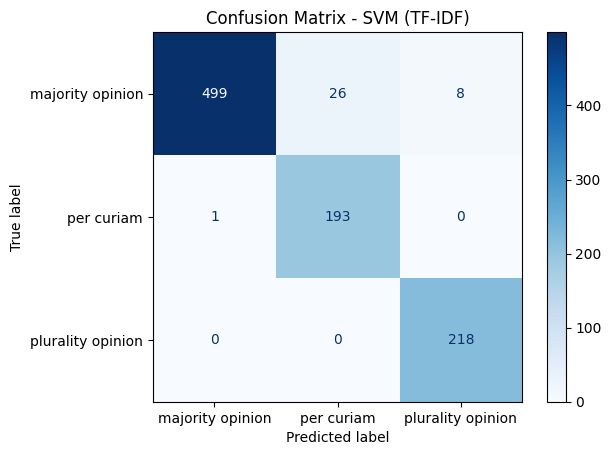

In [298]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#confusion matrix
cm = confusion_matrix(y_test, y_pred)

#plotting
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
plt.figure(figsize=(6,6))
display.plot(cmap='Blues')
plt.title("Confusion Matrix - SVM (TF-IDF)")
plt.show()


*

MODEL 2 (LSTM) PREPROCESSING

In [299]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#tokenizing
max_words = 50000               # vocabulary size
max_len = 600                   # max sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

#padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [300]:
from sklearn.preprocessing import LabelEncoder

#encoding
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

MODEL 2 (LSTM)

In [301]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

#building lstm model
model = Sequential([
    Embedding(input_dim=50000, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')   #multi-class output
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [302]:
#training model
history = model.fit(
    X_train_pad, y_train_enc,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.5731 - loss: 0.9857 - val_accuracy: 0.7235 - val_loss: 0.5493
Epoch 2/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.8380 - loss: 0.4020 - val_accuracy: 0.8902 - val_loss: 0.4198
Epoch 3/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9771 - loss: 0.1166 - val_accuracy: 0.9471 - val_loss: 0.1898
Epoch 4/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.9925 - loss: 0.0327 - val_accuracy: 0.9233 - val_loss: 0.4495
Epoch 5/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9969 - loss: 0.0151 - val_accuracy: 0.9484 - val_loss: 0.3244


In [303]:
#evaluate model
loss, accuracy = model.evaluate(X_test_pad, y_test_enc, verbose=1)
print("Test Accuracy:", accuracy)

30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 323ms/step - accuracy: 0.9454 - loss: 0.3474
Test Accuracy: 0.9523809552192688


VISUALIZATIONS

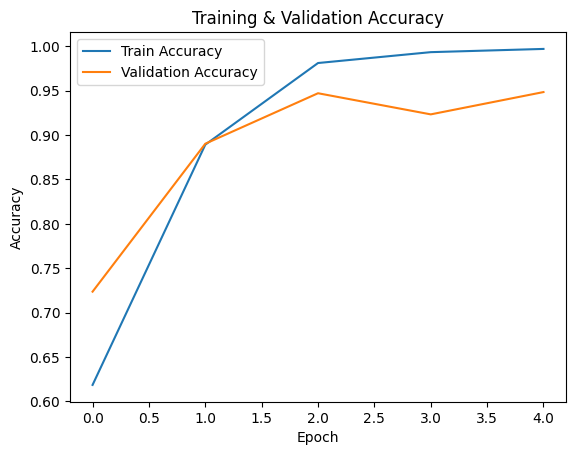

In [304]:
import matplotlib.pyplot as plt
import seaborn as sns

#accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

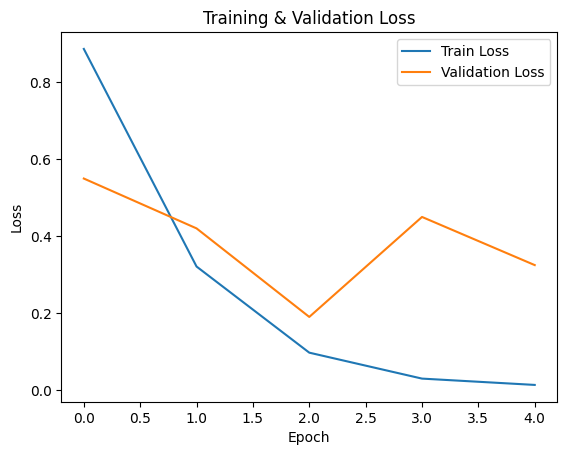

In [305]:
#loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()